In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Customer_Data_Cleaned.csv')

In [5]:
df_backup = df.copy()

In [6]:
df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11098-MAD,Female,30,Yes,Madhya Pradesh,0,31,Deal 1,Yes,No,...,Bank Withdrawal,95.10,6683.40,0.00,0,631.72,7315.12,Stayed,Not Applicable,Not Applicable
1,11114-PUN,Male,51,No,Punjab,5,9,Deal 5,Yes,No,...,Bank Withdrawal,49.15,169.05,0.00,10,122.37,301.42,Churned,Competitor,Competitor had better devices
2,11167-WES,Female,43,Yes,West Bengal,3,28,Deal 1,Yes,Yes,...,Bank Withdrawal,116.05,8297.50,42.57,110,1872.98,10237.91,Stayed,Not Applicable,Not Applicable
3,11179-MAH,Male,35,No,Maharashtra,10,12,No Deal,Yes,No,...,Credit Card,84.40,5969.30,0.00,0,219.39,6188.69,Stayed,Not Applicable,Not Applicable
4,11180-TAM,Male,75,Yes,Tamil Nadu,12,27,Deal 2,Yes,No,...,Credit Card,72.60,4084.35,0.00,140,332.08,4556.43,Stayed,Not Applicable,Not Applicable


In [7]:
df.tail()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
6413,99912-WES,Female,60,Yes,West Bengal,11,26,Deal 4,Yes,No,...,Bank Withdrawal,19.65,244.80,0.0,0,430.69,675.49,Stayed,Not Applicable,Not Applicable
6414,99942-KER,Male,59,Yes,Kerala,8,18,No Deal,Yes,No,...,Bank Withdrawal,69.70,69.70,0.0,0,21.52,91.22,Churned,Attitude,Attitude of service provider
6415,99942-TEL,Female,34,No,Telangana,0,34,No Deal,Yes,Yes,...,Credit Card,70.90,4677.10,0.0,0,1880.02,6557.12,Stayed,Not Applicable,Not Applicable
6416,99962-AND,Female,63,No,Andhra Pradesh,7,1,Deal 2,Yes,Yes,...,Credit Card,91.60,4627.80,0.0,60,937.04,5624.84,Stayed,Not Applicable,Not Applicable
6417,99996-HAR,Male,22,Yes,Haryana,2,8,Deal 5,Yes,No,...,Credit Card,53.55,53.55,0.0,0,16.06,69.61,Joined,Not Applicable,Not Applicable


In [8]:
df.columns = df.columns.str.strip()
churn_df = df[df['Customer_Status'].isin(['Churned', 'Stayed'])]
churn_df.tail()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
6412,99898-MAH,Female,39,No,Maharashtra,2,14,No Deal,Yes,Yes,...,Bank Withdrawal,65.20,3687.85,0.0,0,87.78,3775.63,Stayed,Not Applicable,Not Applicable
6413,99912-WES,Female,60,Yes,West Bengal,11,26,Deal 4,Yes,No,...,Bank Withdrawal,19.65,244.80,0.0,0,430.69,675.49,Stayed,Not Applicable,Not Applicable
6414,99942-KER,Male,59,Yes,Kerala,8,18,No Deal,Yes,No,...,Bank Withdrawal,69.70,69.70,0.0,0,21.52,91.22,Churned,Attitude,Attitude of service provider
6415,99942-TEL,Female,34,No,Telangana,0,34,No Deal,Yes,Yes,...,Credit Card,70.90,4677.10,0.0,0,1880.02,6557.12,Stayed,Not Applicable,Not Applicable
6416,99962-AND,Female,63,No,Andhra Pradesh,7,1,Deal 2,Yes,Yes,...,Credit Card,91.60,4627.80,0.0,60,937.04,5624.84,Stayed,Not Applicable,Not Applicable


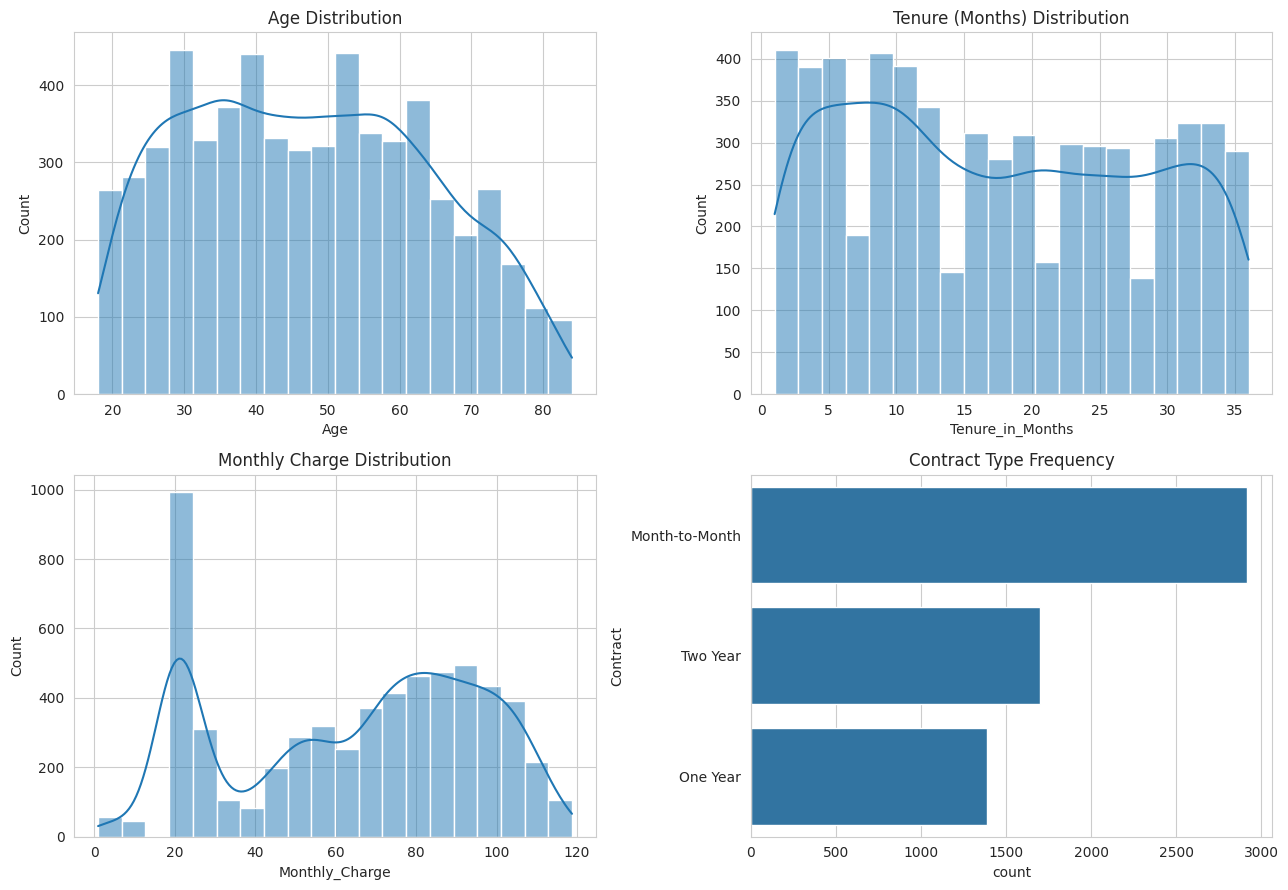

In [9]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(churn_df['Age'], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution')

sns.histplot(churn_df['Tenure_in_Months'], bins=20, kde=True, ax=axes[0,1])
axes[0,1].set_title('Tenure (Months) Distribution')

sns.histplot(churn_df['Monthly_Charge'], bins=20, kde=True, ax=axes[1,0])
axes[1,0].set_title('Monthly Charge Distribution')

order = churn_df['Contract'].value_counts().index
sns.countplot(data=churn_df, y='Contract', order=order, ax=axes[1,1])
axes[1,1].set_title('Contract Type Frequency')

plt.tight_layout()
plt.show()

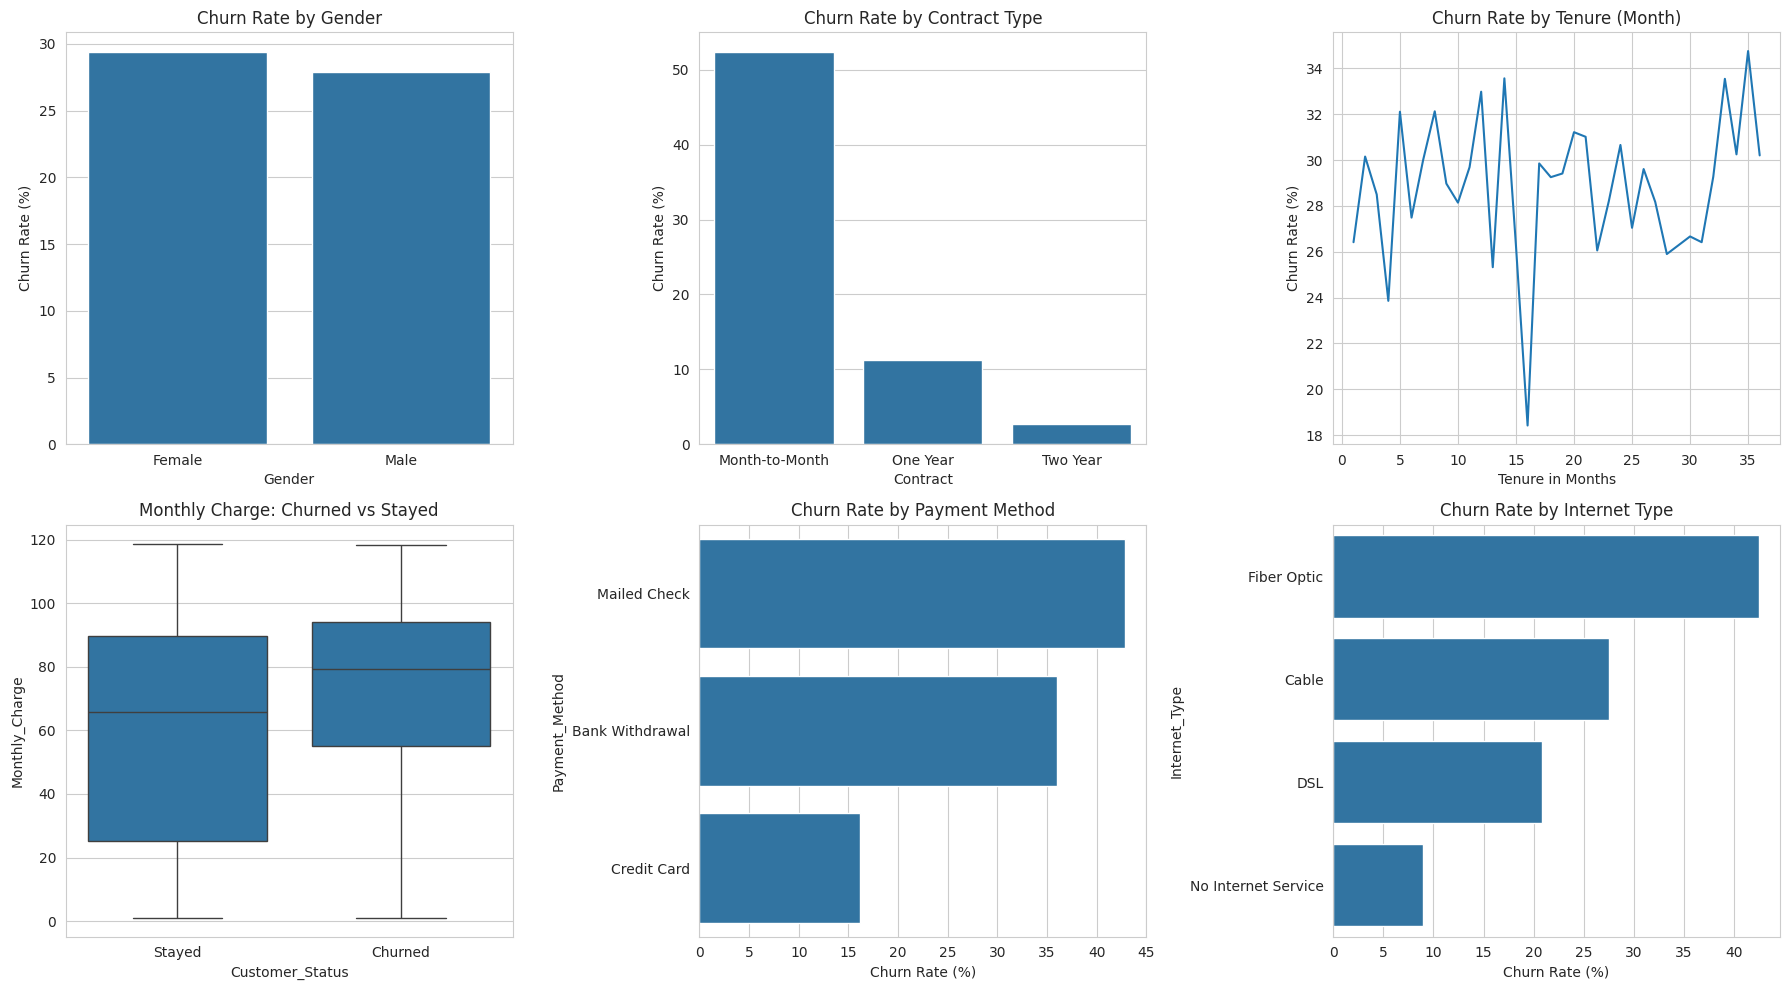

In [10]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Churn vs Gender
g = churn_df.groupby('Gender')['Customer_Status'].apply(lambda x: (x=='Churned').mean()*100)
sns.barplot(x=g.index, y=g.values, ax=axes[0,0])
axes[0,0].set_title('Churn Rate by Gender'); axes[0,0].set_ylabel('Churn Rate (%)')

# 2. Churn vs Contract
g = churn_df.groupby('Contract')['Customer_Status'].apply(lambda x: (x=='Churned').mean()*100).sort_values(ascending=False)
sns.barplot(x=g.index, y=g.values, ax=axes[0,1])
axes[0,1].set_title('Churn Rate by Contract Type'); axes[0,1].set_ylabel('Churn Rate (%)')

# 3. Churn vs Tenure
churn_df['churned_flag'] = (churn_df['Customer_Status']=='Churned').astype(int)
tenure_churn = churn_df.groupby('Tenure_in_Months')['churned_flag'].mean()*100
axes[0,2].plot(tenure_churn.index, tenure_churn.values)
axes[0,2].set_title('Churn Rate by Tenure (Month)'); axes[0,2].set_xlabel('Tenure in Months'); axes[0,2].set_ylabel('Churn Rate (%)')

# 4. Churn vs Monthly Charges
sns.boxplot(data=churn_df, x='Customer_Status', y='Monthly_Charge', ax=axes[1,0])
axes[1,0].set_title('Monthly Charge: Churned vs Stayed')

# 5. Churn vs Payment Method
g = churn_df.groupby('Payment_Method')['Customer_Status'].apply(lambda x: (x=='Churned').mean()*100).sort_values(ascending=False)
sns.barplot(x=g.values, y=g.index, ax=axes[1,1])
axes[1,1].set_title('Churn Rate by Payment Method'); axes[1,1].set_xlabel('Churn Rate (%)')

# 6. Churn vs Internet Type
g = churn_df.groupby('Internet_Type')['Customer_Status'].apply(lambda x: (x=='Churned').mean()*100).sort_values(ascending=False)
sns.barplot(x=g.values, y=g.index, ax=axes[1,2])
axes[1,2].set_title('Churn Rate by Internet Type'); axes[1,2].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.show()